### 第19章 K近邻算法
- K 近邻算法的本质是将指定对象根据已知特征值分类：
    - 在获取各个样本的特征值之后，计算待识别样本的特征值与各个已知分类的样本特征值之间的距离，然后找出k个最邻近的样本，根据k个最邻近样本中占比最高的样本所属的分类，来确定待识别样本的分类。
- 一般情况下，要对参数进行归一化处理。通常使用特征值除以所有特征值中的最大值（或者最大值与最小值的差）
- 取绝对值在求和，这种用绝对值之和表示的距离称为曼哈顿距离
- 计算平方和的平方根，这种距离就是欧氏距离

#### 19.1 数字识别过程
1. 特征提取运算
2. 计算距离，即待识别图像与每一个特征图像的距离
3. 查找最小值
4. 通过反向映射，找到最小值对应的特征图像，进而得到识别结果

In [4]:
# ==============0. 导入包=============
import cv2
import numpy as np

# ==============1. 数据初始化=============
s = "image/"  # 图像所在路径
num = 100  # 共有样本数量
row = 240  # 每个数字图像的行数
col = 240  # 每个数字图像的列数
a = np.zeros((num, row, col))  # 用来存储所有样本的数值
# ===============2. 读取特征图像===============
n = 0  # 用来存储当前图像的编号。
for i in range(0, 10):
    for j in range(1, 11):
        a[n, :, :] = cv2.imread(s + str(i) + "/" + str(i) + "-" + str(j) + ".bmp", 0)
        n = n + 1

# ===============3. 提取特征图像的特征值=============
# 用来存储所有样本的特征值，每一个元素对应原始图像 5*5 区域内的像素值为255的个数。
feature = np.zeros((num, round(row / 5), round(col / 5)))  
print(feature.shape)  # 看看feature的shape长什么样子
print(row)            # 看看row的值，有多少个特征（100）个
for ni in range(0, num):
    for nr in range(0, row):
        for nc in range(0, col):
            if a[ni, nr, nc] == 255:
                feature[ni, int(nr / 5), int(nc / 5)] += 1
f = feature  # 简化变量名称

(100, 48, 48)
240


In [19]:
# ===============4. 计算待识别图像的特征值===============
o = cv2.imread("image/stand/8.bmp", 0)  # 读取待测图像
##读取图像值
of = np.zeros((round(row / 5), round(col / 5)))  # 用来存储测试图像的特征值
for nr in range(0, row):
    for nc in range(0, col):
        if o[nr, nc] == 255:
            of[int(nr / 5), int(nc / 5)] += 1
# ==========5. 计算待识别图像与特征图像之间的距离================
# 数组 d 中的索引号对应特征图像的编号，d[mn]表示待识别图像与数字“m”的第n个特征图像之间的距离
d = np.zeros(100)
for i in range(0, 100):
    d[i] = np.sum((of - f[i, :, :]) * (of - f[i, :, :]))
# ================6. 获取k个最短距离及其索引====================
d = d.tolist()
temp = []
Inf = max(d)
print(Inf)
k = 3   # 选择的邻居的数量
for i in range(k):
    temp.append(d.index(min(d)))
    d[d.index(min(d))] = Inf    # 最小值替换为最大值，确保在下一次查找最小值的过程中不会被重复找到
print(temp)   # 被识别为哪些特征图像

1332865.0
[80, 82, 72]


In [20]:
# ===========================7. 识别=========================
temp = [i / 10 for i in temp]
# 数组r用来存储结果，r[0]表示k近邻中0的个数，r[n]K近邻中n的个数
r = np.zeros(10)
for i in temp:
    r[int(i)] += 1
print("当前的数字可能为:" + str(np.argmax(r)))


当前的数字可能为:8


#### 19.2 K 近邻模块
1. 生成一个空的模型
`knn = cv2.ml.KNearest_create()`
2. 使用训练数据（原始特征值）、训练数据的响应值（训练数据的标签、分类信息），根据数据的行、列完成训练，生成可以使用的模型
    - `knn.train(trainData, cv2.ml.ROW_SAMPLE, trainLabels)`
        - `trainData` 是训练数据的特征值
        - `cv2.ml.ROW_SAMPLE` 是数据类型，当前是行形式；也可以是列形式 `cv2.ml.COL_SAMPLE`
        - `trainLabels` 是训练数据特征值所对应的标签值
3. 将要处理对象的特征值和 k 值作为参数，传递给训练好的模型，得出计算结果
    - `ret, result, neighbours, dist = knn.findNearest(test, k)`
        - `ret` 是 float 型的返回结果
        - `result` 是 numpy.ndarray 的 k 近邻算法的运算结果
        - `neighbours` 是 k 个邻居的标签
        - `dist` 是 k 个邻居的距离
        - `test` 是需要处理对象的特征值
        - `k` 是 K 近邻算法中 k 值大小

trainData.shape:  (40, 2)
tdLable.shape:  (40, 1)
待识别的数据是： [[80.  5.]
 [15. 57.]
 [55. 86.]]
当前随机数可以判定为类型： [[0.]
 [0.]
 [1.]]
距离当前点最近的5个邻居是： [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]]
5个最近邻居的距离:  [[2610. 2797. 2857. 2925. 3112.]
 [ 800. 1044. 1096. 1160. 1205.]
 [ 436.  533.  578.  593.  674.]]


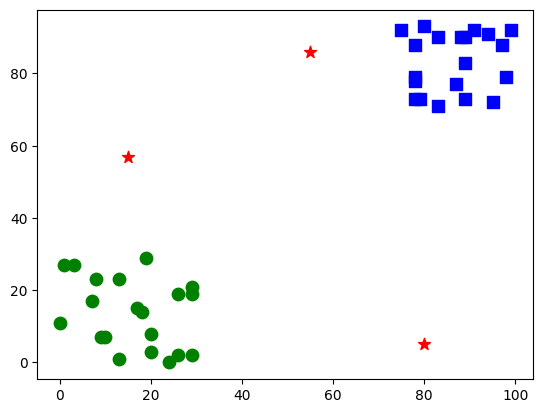

In [17]:
# ================导入库===================
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==============1. 生成模拟数据及标签=====================
# 1.1 模拟数据
rand1 = np.random.randint(0, 30, (20, 2)).astype(np.float32)
rand2 = np.random.randint(70, 100, (20, 2)).astype(np.float32)
trainData = np.vstack((rand1, rand2))
print("trainData.shape: ", trainData.shape)
# 1.2 设置数据标签
r1Label = np.zeros((20, 1)).astype(np.float32)
r2Label = np.ones((20, 1)).astype(np.float32)
tdLable = np.vstack((r1Label, r2Label))
print("tdLable.shape: ", tdLable.shape)
# 1.3 显示数据
# trainData[tdLable.ravel() == 0]：把标签数组展平，找出等于0的位置(布尔索引); 再从训练数据中选择对应标签为0的样本
g = trainData[tdLable.ravel() == 0]
plt.scatter(g[:, 0], g[:, 1], s=80, c="g", marker="o")
b = trainData[tdLable.ravel() == 1]
plt.scatter(b[:, 0], b[:, 1], s=80, c="b", marker="s")

# ===============2. 模拟待识别数据=====================
test = np.random.randint(0, 100, (3, 2)).astype(np.float32)
plt.scatter(test[:, 0], test[:, 1], s=80, c="r", marker="*")
print("待识别的数据是：", test)
# ===============3. 完成分类=====================
knn = cv2.ml.KNearest_create()  # 创建KNN分类器对象
knn.train(trainData, cv2.ml.ROW_SAMPLE, tdLable)    # 训练模型
ret, results, neighbours, dist = knn.findNearest(test, 5)   # 测试模型
# ===============显示结果=====================
print("当前随机数可以判定为类型：", results)
print("距离当前点最近的5个邻居是：", neighbours)
print("5个最近邻居的距离: ", dist)
plt.show()

#### 19.3 K 近邻手写数字识别

In [20]:
import cv2
import numpy as np
import os

# ==============1. 训练数据处理==================
# 读取（设置）样本（特征）图像的值
s = "image/"  # 图像所在路径
num = 100  # 共有样本数量
row = 240  # 每个数字图像的行数
col = 240  # 每个数字图像的列数
a = np.zeros((num, row, col))  # 用来存储所有样本的数值
n = 0  # 用来存储当前图像的编号。
# 读取特征图像
for i in range(0, 10):
    for j in range(1, 11):
        a[n, :, :] = cv2.imread(s + str(i) + "/" + str(i) + "-" + str(j) + ".bmp", 0)
        n = n + 1
# 提取样本图像的特征
feature = np.zeros((num, round(row / 5), round(col / 5)))  # 用来存储所有样本的特征值
for ni in range(0, num):
    for nr in range(0, row):
        for nc in range(0, col):
            if a[ni, nr, nc] == 255:
                feature[ni, int(nr / 5), int(nc / 5)] += 1
f = feature  # 简化变量名称
# 将feature处理为单行形式
train = feature[:, :].reshape(-1, round(row / 5) * round(col / 5)).astype(np.float32)
# 为特征值贴标签
trainLabels = [int(i / 10) for i in range(0, 100)]
trainLabels = np.asarray(trainLabels)   # 如果 trainLabels 已经是 NumPy 数组，返回原数组；否则创建新数组。
# =================2. 待识别数据处理====================
o = cv2.imread(s + "test/4.bmp", 0)  # 读取待测图像

if o is None:
    raise ValueError("Image not found or could not be loaded. Check the file path: " + os.path.abspath(s + "test/5.bmp"))
of = np.zeros((round(row / 5), round(col / 5)))  # 用来存储测试图像的特征值
for nr in range(0, row):
    for nc in range(0, col):
        if o[nr, nc] == 255:
            of[int(nr / 5), int(nc / 5)] += 1
# 处理为函数所需要的格式
test = of.reshape(-1, round(row / 5) * round(col / 5)).astype(np.float32)
# ==================3. 完成分类=======================
knn = cv2.ml.KNearest_create()
knn.train(train, cv2.ml.ROW_SAMPLE, trainLabels)
ret, result, neighbours, dist = knn.findNearest(test, k=5)
# ===============显示结果=====================
print("当前随机数可以判定为类型：", result)
print("距离当前点最近的5个邻居是：", neighbours)
print("5个最近邻居的距离: ", dist)


当前随机数可以判定为类型： [[4.]]
距离当前点最近的5个邻居是： [[4. 4. 2. 7. 1.]]
5个最近邻居的距离:  [[ 65638.  94839.  98032.  99631. 100733.]]
